## 📦 Cell 1 — Install Dependencies

In [1]:
# Run once if not installed
import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'install',
                'xgboost', 'scikit-learn', 'pandas', 'numpy',
                'matplotlib', 'seaborn', 'joblib'], check=True)
print('✅ All dependencies ready')

✅ All dependencies ready


## 📂 Cell 2 — Load Data

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os, joblib, warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('../backend/data/ml_training_data_final.csv')

print(f'✅ Loaded: {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'\n📊 Item type distribution:')
print(df['item_type'].value_counts())
print(f'\n📊 User type distribution:')
print(df['user_type'].value_counts())
df.head()

✅ Loaded: 31,905 rows × 16 columns

📊 Item type distribution:
item_type
destination    20801
event           6658
trek            4446
Name: count, dtype: int64

📊 User type distribution:
user_type
family    10794
couple    10577
solo      10534
Name: count, dtype: int64


,item_id,item_type,item_name,country,user_type,interest,vibe,budget_usd,travel_month,popularity_score,season_match,difficulty_match,interest_match,budget_match,is_offbeat,recommendation_score
0,ec438722-1c9e-448e-aac1-3f680147b1c1,destination,Cali,Colombia,family,nature,spiritual,4140.07,8,0.50,1.0,0.6,0.30,1.00,0,0.6973
1,2351880f-c2eb-4f51-ad7f-f78e8eeeb96d,destination,Kuwait City,Kuwait,solo,spiritual,luxury,1036.72,4,0.50,1.0,0.6,0.30,1.00,0,0.6693
2,e1b19aa4-73fe-4190-88a3-20b0e27ceee7,event,Glastonbury Festival,UK,solo,adventure,spiritual,6508.51,5,0.96,1.0,0.7,0.30,1.00,0,0.8065
3,313e9d90-18c0-458b-b95e-d3055009d4c7,destination,Sapa,Vietnam,solo,offbeat,luxury,284.48,2,0.50,1.0,0.6,0.45,0.10,1,0.7194
4,3264edc9-1b3f-42be-be41-fb8d847c787d,destination,Mostar,Bosnia and Herzegovina,couple,culture,budget,398.02,9,0.50,1.0,0.6,0.30,0.35,0,0.5800


## 🔍 Cell 3 — Exploratory Data Analysis

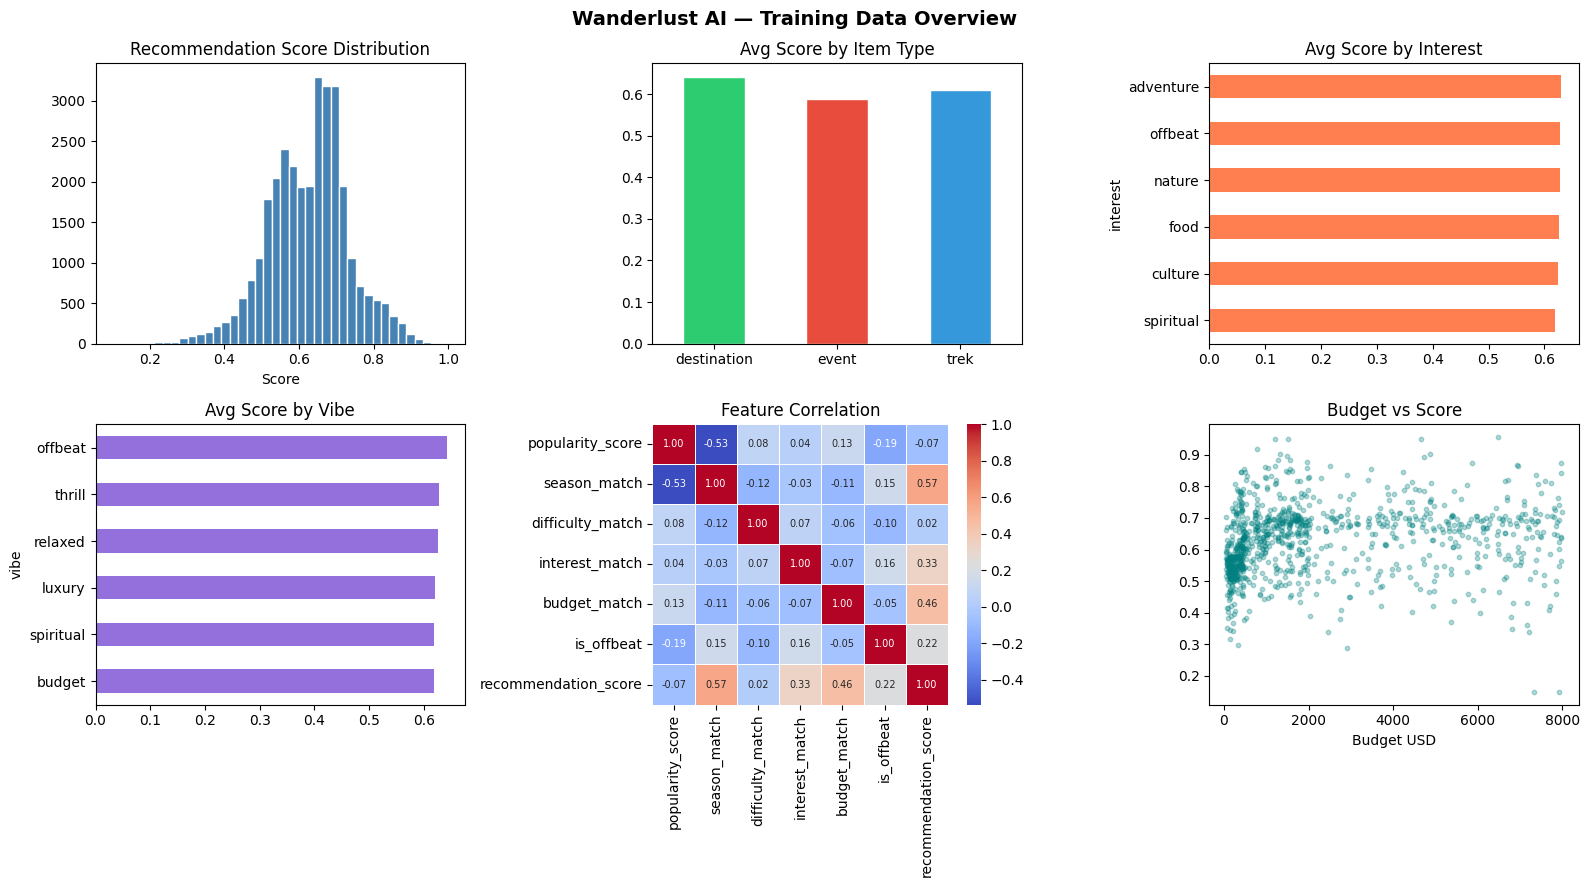

✅ EDA chart saved to ml/eda_overview.png


In [3]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Wanderlust AI — Training Data Overview', fontsize=14, fontweight='bold')

# 1. Score distribution
axes[0,0].hist(df['recommendation_score'], bins=40, color='steelblue', edgecolor='white')
axes[0,0].set_title('Recommendation Score Distribution')
axes[0,0].set_xlabel('Score')

# 2. Score by item type
df.groupby('item_type')['recommendation_score'].mean().plot(
    kind='bar', ax=axes[0,1], color=['#2ecc71','#e74c3c','#3498db'], edgecolor='white')
axes[0,1].set_title('Avg Score by Item Type')
axes[0,1].set_xlabel('')
axes[0,1].tick_params(axis='x', rotation=0)

# 3. Score by interest
df.groupby('interest')['recommendation_score'].mean().sort_values().plot(
    kind='barh', ax=axes[0,2], color='coral')
axes[0,2].set_title('Avg Score by Interest')

# 4. Score by vibe
df.groupby('vibe')['recommendation_score'].mean().sort_values().plot(
    kind='barh', ax=axes[1,0], color='mediumpurple')
axes[1,0].set_title('Avg Score by Vibe')

# 5. Correlation heatmap
num_cols = ['popularity_score','season_match','difficulty_match',
            'interest_match','budget_match','is_offbeat','recommendation_score']
corr = df[num_cols].corr()
sns.heatmap(corr, ax=axes[1,1], annot=True, fmt='.2f', cmap='coolwarm',
            annot_kws={'size':7}, linewidths=0.5)
axes[1,1].set_title('Feature Correlation')

# 6. Budget vs score scatter
sample = df.sample(1000, random_state=42)
axes[1,2].scatter(sample['budget_usd'], sample['recommendation_score'],
                  alpha=0.3, color='teal', s=10)
axes[1,2].set_title('Budget vs Score')
axes[1,2].set_xlabel('Budget USD')

plt.tight_layout()
plt.savefig('../backend/ml/eda_overview.png', dpi=120, bbox_inches='tight')
plt.show()
print('✅ EDA chart saved to ml/eda_overview.png')

## ⚙️ Cell 4 — Feature Engineering

In [4]:
from sklearn.preprocessing import LabelEncoder

df_model = df.copy()

# ── Encode categorical columns ──
cat_cols = ['item_type', 'user_type', 'interest', 'vibe']
encoders = {}

for col in cat_cols:
    le = LabelEncoder()
    df_model[col + '_enc'] = le.fit_transform(df_model[col].astype(str))
    encoders[col] = le
    print(f'  {col}: {list(le.classes_)}')

# ── Feature columns ──
FEATURE_COLS = [
    'item_type_enc',
    'user_type_enc',
    'interest_enc',
    'vibe_enc',
    'budget_usd',
    'travel_month',
    'popularity_score',
    'season_match',
    'difficulty_match',
    'interest_match',
    'budget_match',
    'is_offbeat',
]

TARGET_COL = 'recommendation_score'

X = df_model[FEATURE_COLS]
y = df_model[TARGET_COL]

print(f'\n✅ Features: {len(FEATURE_COLS)}')
print(f'✅ X shape:  {X.shape}')
print(f'✅ y shape:  {y.shape}')
print(f'✅ y range:  {y.min():.3f} → {y.max():.3f}')
X.head()

  item_type: ['destination', 'event', 'trek']
  user_type: ['couple', 'family', 'solo']
  interest: ['adventure', 'culture', 'food', 'nature', 'offbeat', 'spiritual']
  vibe: ['budget', 'luxury', 'offbeat', 'relaxed', 'spiritual', 'thrill']

✅ Features: 12
✅ X shape:  (31905, 12)
✅ y shape:  (31905,)
✅ y range:  0.100 → 1.000


,item_type_enc,user_type_enc,interest_enc,vibe_enc,budget_usd,travel_month,popularity_score,season_match,difficulty_match,interest_match,budget_match,is_offbeat
0,0,1,3,4,4140.07,8,0.50,1.0,0.6,0.30,1.00,0
1,0,2,5,1,1036.72,4,0.50,1.0,0.6,0.30,1.00,0
2,1,2,0,4,6508.51,5,0.96,1.0,0.7,0.30,1.00,0
3,0,2,4,1,284.48,2,0.50,1.0,0.6,0.45,0.10,1
4,0,0,1,0,398.02,9,0.50,1.0,0.6,0.30,0.35,0


## ✂️ Cell 5 — Train / Validation / Test Split

In [5]:
from sklearn.model_selection import train_test_split

# 70% train | 15% val | 15% test
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42)

print(f'✅ Train:      {X_train.shape[0]:,} rows ({X_train.shape[0]/len(X)*100:.0f}%)')
print(f'✅ Validation: {X_val.shape[0]:,} rows ({X_val.shape[0]/len(X)*100:.0f}%)')
print(f'✅ Test:       {X_test.shape[0]:,} rows ({X_test.shape[0]/len(X)*100:.0f}%)')

✅ Train:      22,333 rows (70%)
✅ Validation: 4,786 rows (15%)
✅ Test:       4,786 rows (15%)


## 🚀 Cell 6 — Train XGBoost Model

In [6]:
from xgboost import XGBRegressor

model = XGBRegressor(
    n_estimators     = 500,
    max_depth        = 6,
    learning_rate    = 0.05,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    min_child_weight = 3,
    reg_alpha        = 0.1,
    reg_lambda       = 1.0,
    random_state     = 42,
    n_jobs           = -1,
    verbosity        = 0,
)

print('🚀 Training XGBoost...')
model.fit(
    X_train, y_train,
    eval_set        = [(X_train, y_train), (X_val, y_val)],
    verbose         = 50,
)
print('\n✅ Training complete!')

🚀 Training XGBoost...
[0]	validation_0-rmse:0.10340	validation_1-rmse:0.10599
[50]	validation_0-rmse:0.03326	validation_1-rmse:0.03425
[100]	validation_0-rmse:0.02597	validation_1-rmse:0.02715
[150]	validation_0-rmse:0.02435	validation_1-rmse:0.02573
[200]	validation_0-rmse:0.02349	validation_1-rmse:0.02508
[250]	validation_0-rmse:0.02294	validation_1-rmse:0.02473
[300]	validation_0-rmse:0.02252	validation_1-rmse:0.02456
[350]	validation_0-rmse:0.02216	validation_1-rmse:0.02442
[400]	validation_0-rmse:0.02190	validation_1-rmse:0.02435
[450]	validation_0-rmse:0.02167	validation_1-rmse:0.02433
[499]	validation_0-rmse:0.02144	validation_1-rmse:0.02431

✅ Training complete!


## 📊 Cell 7 — Evaluate Model

In [7]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def evaluate(name, X_eval, y_eval):
    preds = model.predict(X_eval)
    mae   = mean_absolute_error(y_eval, preds)
    rmse  = np.sqrt(mean_squared_error(y_eval, preds))
    r2    = r2_score(y_eval, preds)
    print(f'  {name:<12} MAE: {mae:.4f}  RMSE: {rmse:.4f}  R²: {r2:.4f}')
    return preds

print('📊 Model Performance:')
print('  ' + '-'*52)
evaluate('Train',      X_train, y_train)
evaluate('Validation', X_val,   y_val)
test_preds = evaluate('Test',       X_test,  y_test)
print('  ' + '-'*52)
print()
print('💡 R² > 0.85 = excellent  |  MAE < 0.05 = excellent')

📊 Model Performance:
  ----------------------------------------------------
  Train        MAE: 0.0182  RMSE: 0.0214  R²: 0.9605
  Validation   MAE: 0.0206  RMSE: 0.0243  R²: 0.9517
  Test         MAE: 0.0209  RMSE: 0.0249  R²: 0.9473
  ----------------------------------------------------

💡 R² > 0.85 = excellent  |  MAE < 0.05 = excellent


## 📈 Cell 8 — Visualize Results

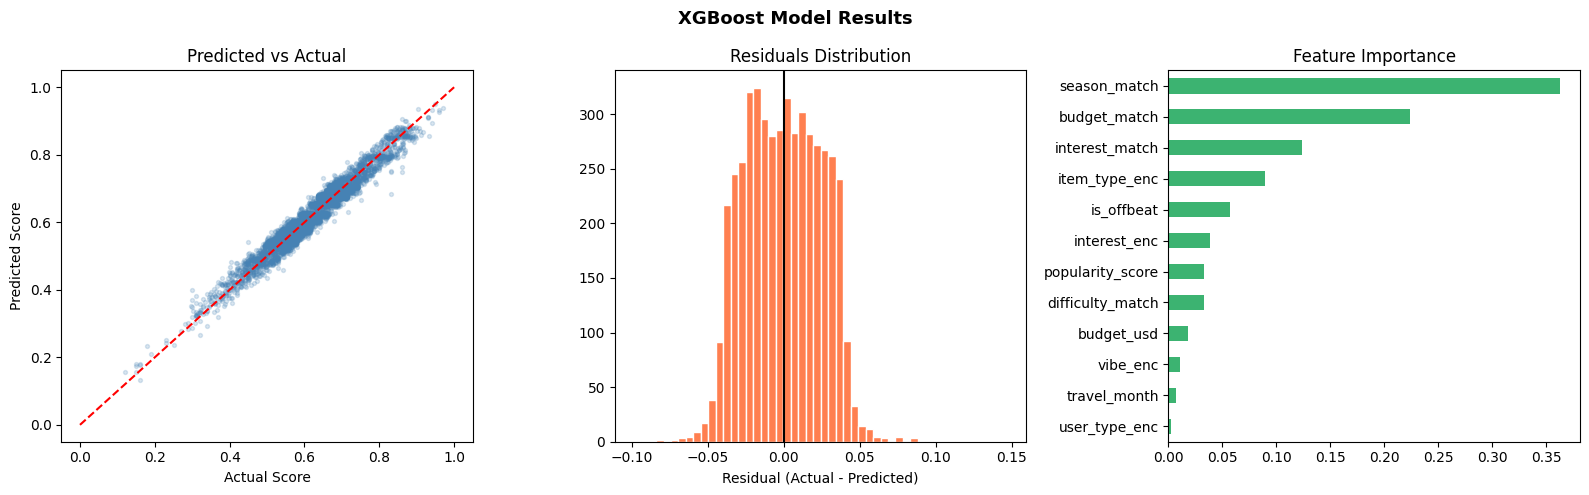

✅ Results chart saved to ml/model_results.png


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('XGBoost Model Results', fontsize=13, fontweight='bold')

# 1. Predicted vs Actual
axes[0].scatter(y_test, test_preds, alpha=0.2, s=8, color='steelblue')
axes[0].plot([0, 1], [0, 1], 'r--', linewidth=1.5)
axes[0].set_xlabel('Actual Score')
axes[0].set_ylabel('Predicted Score')
axes[0].set_title('Predicted vs Actual')

# 2. Residuals
residuals = y_test.values - test_preds
axes[1].hist(residuals, bins=50, color='coral', edgecolor='white')
axes[1].axvline(0, color='black', linewidth=1.5)
axes[1].set_title('Residuals Distribution')
axes[1].set_xlabel('Residual (Actual - Predicted)')

# 3. Feature Importance
importance = pd.Series(model.feature_importances_, index=FEATURE_COLS)
importance.sort_values().plot(kind='barh', ax=axes[2], color='mediumseagreen')
axes[2].set_title('Feature Importance')

plt.tight_layout()
plt.savefig('../backend/ml/model_results.png', dpi=120, bbox_inches='tight')
plt.show()
print('✅ Results chart saved to ml/model_results.png')

## 💾 Cell 9 — Save Model & Encoders

In [9]:
os.makedirs('../backend/ml', exist_ok=True)

# Save model
joblib.dump(model, '../backend/ml/recommendation_model.pkl')

# Save encoders
joblib.dump(encoders, '../backend/ml/label_encoders.pkl')

# Save feature column order (CRITICAL — must match at inference time)
joblib.dump(FEATURE_COLS, '../backend/ml/feature_columns.pkl')

print('✅ Saved:')
print('   backend/ml/recommendation_model.pkl')
print('   backend/ml/label_encoders.pkl')
print('   backend/ml/feature_columns.pkl')

# Quick size check
for f in ['recommendation_model.pkl', 'label_encoders.pkl', 'feature_columns.pkl']:
    path = f'../backend/ml/{f}'
    size = os.path.getsize(path) / 1024
    print(f'   {f}: {size:.1f} KB')

✅ Saved:
   backend/ml/recommendation_model.pkl
   backend/ml/label_encoders.pkl
   backend/ml/feature_columns.pkl
   recommendation_model.pkl: 2024.4 KB
   label_encoders.pkl: 1.3 KB
   feature_columns.pkl: 0.2 KB


## 🧪 Cell 10 — Sanity Check (Test Inference)

In [10]:
# Simulate what the FastAPI route will do
loaded_model    = joblib.load('../backend/ml/recommendation_model.pkl')
loaded_encoders = joblib.load('../backend/ml/label_encoders.pkl')
loaded_features = joblib.load('../backend/ml/feature_columns.pkl')

def predict_score(item_type, user_type, interest, vibe,
                  budget_usd, travel_month, popularity_score,
                  season_match, difficulty_match, interest_match,
                  budget_match, is_offbeat):
    row = {
        'item_type_enc':    loaded_encoders['item_type'].transform([item_type])[0],
        'user_type_enc':    loaded_encoders['user_type'].transform([user_type])[0],
        'interest_enc':     loaded_encoders['interest'].transform([interest])[0],
        'vibe_enc':         loaded_encoders['vibe'].transform([vibe])[0],
        'budget_usd':       budget_usd,
        'travel_month':     travel_month,
        'popularity_score': popularity_score,
        'season_match':     season_match,
        'difficulty_match': difficulty_match,
        'interest_match':   interest_match,
        'budget_match':     budget_match,
        'is_offbeat':       is_offbeat,
    }
    X_input = pd.DataFrame([row])[loaded_features]
    score = loaded_model.predict(X_input)[0]
    return round(float(score), 4)

# Test cases
test_cases = [
    dict(item_type='trek', user_type='solo', interest='adventure', vibe='thrill',
         budget_usd=800, travel_month=10, popularity_score=0.9,
         season_match=1.0, difficulty_match=1.0, interest_match=0.9,
         budget_match=0.95, is_offbeat=1),

    dict(item_type='event', user_type='family', interest='culture', vibe='relaxed',
         budget_usd=2000, travel_month=10, popularity_score=0.85,
         season_match=1.0, difficulty_match=1.0, interest_match=0.85,
         budget_match=0.9, is_offbeat=0),

    dict(item_type='destination', user_type='couple', interest='offbeat', vibe='offbeat',
         budget_usd=500, travel_month=3, popularity_score=0.4,
         season_match=0.2, difficulty_match=0.6, interest_match=0.8,
         budget_match=0.5, is_offbeat=1),

    dict(item_type='trek', user_type='family', interest='nature', vibe='relaxed',
         budget_usd=300, travel_month=7, popularity_score=0.5,
         season_match=0.2, difficulty_match=0.1, interest_match=0.5,
         budget_match=0.3, is_offbeat=0),  # ← should score LOW
]

labels = [
    '✅ Solo + Adventure Trek (should be HIGH)',
    '✅ Family + Culture Event (should be HIGH)',
    '⚠️  Offbeat Couple, bad season (should be MEDIUM)',
    '❌ Family doing hard winter trek (should be LOW)',
]

print('🧪 Inference Test:\n')
for label, tc in zip(labels, test_cases):
    score = predict_score(**tc)
    bar = '█' * int(score * 20)
    print(f'{label}')
    print(f'   Score: {score:.4f}  [{bar:<20}]\n')

🧪 Inference Test:

✅ Solo + Adventure Trek (should be HIGH)
   Score: 0.9591  [███████████████████ ]

✅ Family + Culture Event (should be HIGH)
   Score: 0.9276  [██████████████████  ]

⚠️  Offbeat Couple, bad season (should be MEDIUM)
   Score: 0.5446  [██████████          ]

❌ Family doing hard winter trek (should be LOW)
   Score: 0.3818  [███████             ]

